# Outlier Detection


# 1. What are Outliers?

### Definition

Outliers are observations that are unusually far from most other values in a dataset.

### Real-life Example

A salary dataset contains ₹30,000, ₹32,000, ₹31,000, ₹29,000 and ₹2,00,000. The last value may be an outlier.

### Formula / Numerical Example

There is no single formula for every outlier. Two common methods are:

$$IQR = Q_3-Q_1$$

$$z=\frac{x-\mu}{\sigma}$$

Where:
- $Q_1$ = first quartile
- $Q_3$ = third quartile
- $x$ = individual value
- $\mu$ = population mean
- $\sigma$ = population standard deviation

### Python Implementation


In [1]:
import numpy as np
data=np.array([10,12,11,13,12,10,100])
print("Data:",data)
print("Minimum:",data.min())
print("Maximum:",data.max())

Data: [ 10  12  11  13  12  10 100]
Minimum: 10
Maximum: 100


### AI/ML Example

Outliers can strongly influence some statistical estimates and machine-learning models. They should be investigated before removal because they may be errors or genuine rare observations.


# 2. Types of Outliers

### Definition

Common types include global or point outliers, contextual outliers, and collective outliers.

### Real-life Example

A very large transaction can be a point outlier; 35°C may be unusual in winter but normal in summer, making it contextual.

### Formula / Numerical Example

There is no single formula for all outlier types. A simple point outlier can sometimes be examined with:

$$z=\frac{x-\mu}{\sigma}$$

A large absolute Z-score means the value is far from the mean in standard-deviation units.

### Python Implementation


In [3]:
import numpy as np
data=np.array([20,21,19,22,20,100])
mean=np.mean(data)
std=np.std(data)
z_scores=(data-mean)/std
print("Z-scores:",z_scores)

Z-scores: [-0.46047074 -0.42677776 -0.49416372 -0.39308478 -0.46047074  2.23496772]


### AI/ML Example

Different outlier types appear in fraud detection, sensor monitoring, and anomaly detection. Knowing the type helps us choose an appropriate detection method.


# 3. Detecting Outliers

### Definition

Outlier detection is the process of identifying observations that are unusually different from the majority of the data.

### Real-life Example

Delivery times are 25, 28, 30, 27, 29 and 120 minutes. The 120-minute observation should be investigated.

### Formula / Numerical Example

Two common statistical approaches are:

$$IQR=Q_3-Q_1$$
$$Lower\ Bound=Q_1-1.5(IQR)$$
$$Upper\ Bound=Q_3+1.5(IQR)$$

and

$$z=\frac{x-\mu}{\sigma}$$

Values outside the IQR bounds or with large absolute Z-scores can be flagged as potential outliers.

### Python Implementation


In [5]:
import numpy as np
data=np.array([25,28,30,27,29,120])
q1=np.percentile(data,25)
q3=np.percentile(data,75)
iqr=q3-q1
lower=q1-1.5*iqr
upper=q3+1.5*iqr
outliers=data[(data<lower)|(data>upper)]
print("Lower Bound:",lower)
print("Upper Bound:",upper)
print("Potential Outliers:",outliers)

Lower Bound: 23.5
Upper Bound: 33.5
Potential Outliers: [120]


### AI/ML Example

Outlier detection is often part of data preprocessing. Flagged observations should be examined instead of automatically deleted because they may contain useful information.


# 4. IQR Method

### Definition

The IQR method detects potential outliers using the middle 50% of the data.

### Real-life Example

Most product prices are similar, but one is extremely high. IQR can help determine whether it falls outside the usual range.

### Formula / Numerical Example

$$IQR=Q_3-Q_1$$
$$Lower\ Bound=Q_1-1.5(IQR)$$
$$Upper\ Bound=Q_3+1.5(IQR)$$

Where:
- $Q_1$ = 25th percentile
- $Q_3$ = 75th percentile
- $IQR$ = interquartile range

If $Q_1=20$ and $Q_3=40$:

$$IQR=40-20=20$$
$$Lower\ Bound=20-1.5(20)=-10$$
$$Upper\ Bound=40+1.5(20)=70$$

Values below -10 or above 70 are potential outliers.

### Python Implementation


In [7]:
import numpy as np
data=np.array([10,12,14,15,16,18,20,100])
q1=np.percentile(data,25)
q3=np.percentile(data,75)
iqr=q3-q1
lower=q1-1.5*iqr
upper=q3+1.5*iqr
print("Q1:",q1)
print("Q3:",q3)
print("IQR:",iqr)
print("Potential Outliers:",data[(data<lower)|(data>upper)])

Q1: 13.5
Q3: 18.5
IQR: 5.0
Potential Outliers: [100]


### AI/ML Example

The IQR method can flag extreme numerical observations during preprocessing. It is based on quartiles and does not require a normal-distribution assumption.


# 5. Z-Score Method

### Definition

A Z-score tells us how many standard deviations a value is above or below the mean.

### Real-life Example

If one exam score is many standard deviations away from the class average, it will have a large absolute Z-score.

### Formula / Numerical Example

$$z=\frac{x-\mu}{\sigma}$$

Where:
- $z$ = Z-score
- $x$ = individual value
- $\mu$ = population mean
- $\sigma$ = population standard deviation

A commonly used rule is:

$$|z|>3$$

For $x=100$, $\mu=50$, and $\sigma=10$:

$$z=\frac{100-50}{10}=5$$

The value is 5 standard deviations above the mean.

### Python Implementation


In [9]:
import numpy as np
from scipy.stats import zscore
data=np.array([10,11,12,10,11,12,50])
z_scores=zscore(data)
print("Z-scores:",z_scores)
print("Potential Outliers:",data[np.abs(z_scores)>2])

Z-scores: [-0.48078663 -0.40762344 -0.33446026 -0.48078663 -0.40762344 -0.33446026
  2.44574066]
Potential Outliers: [50]


### AI/ML Example

Z-scores can flag unusually high or low feature values. The threshold depends on the problem, and Z-score detection is most appropriate when using the mean and standard deviation makes sense for the data.


# 6. Box Plot

### Definition

A box plot summarizes numerical data using quartiles, the median, and whiskers. Points beyond the whiskers are commonly shown as potential outliers.

### Real-life Example

A box plot of employee salaries can quickly reveal unusually high or low salaries.

### Formula / Numerical Example

$$IQR=Q_3-Q_1$$

Common fences are:

$$Q_1-1.5(IQR)$$
$$Q_3+1.5(IQR)$$

Where:
- $Q_1$ = first quartile
- $Q_3$ = third quartile
- $IQR$ = interquartile range

### Python Implementation


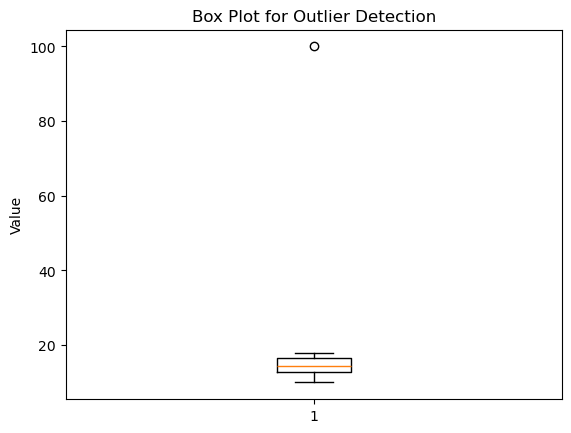

In [11]:
import matplotlib.pyplot as plt
data=[10,12,13,14,15,16,18,100]
plt.boxplot(data)
plt.ylabel("Value")
plt.title("Box Plot for Outlier Detection")
plt.show()

### AI/ML Example

Box plots are useful during exploratory data analysis. They summarize the center and spread and make observations beyond the whiskers easy to inspect.


# 7. Scatter Plot

### Definition

A scatter plot displays pairs of numerical values as points. Points far from the main pattern may be potential outliers.

### Real-life Example

When advertising cost is plotted against sales, one point far from the general pattern may need investigation.

### Formula / Numerical Example

A scatter plot has no separate outlier formula. Each observation is represented as:

$$(x_i,y_i)$$

Where:
- $x_i$ = first variable value for observation i
- $y_i$ = second variable value for observation i
- $i$ = observation number

### Python Implementation


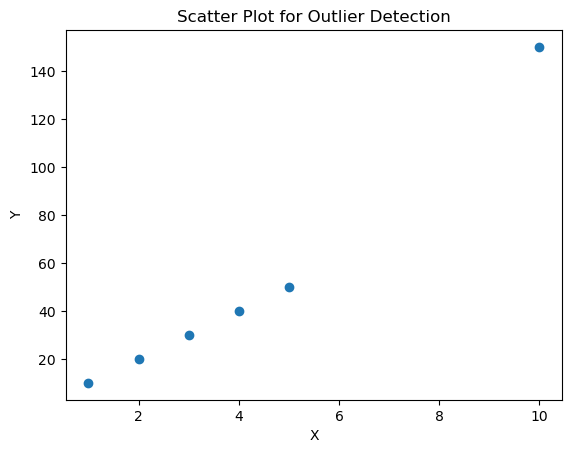

In [13]:
import matplotlib.pyplot as plt
x=[1,2,3,4,5,10]
y=[10,20,30,40,50,150]
plt.scatter(x,y)
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Scatter Plot for Outlier Detection")
plt.show()

### AI/ML Example

Scatter plots help identify unusual observations involving two numerical features. Visual inspection is useful for exploration and can be combined with statistical or model-based methods.
